# 02B · EDA y análisis espacial de siniestros con víctimas
## Actividad 3.1 del cronograma

Este notebook caracteriza la distribución temporal, territorial y puntual de los siniestros con personas heridas o fallecidas entre 2018 y 2024. El análisis es descriptivo: identifica concentración espacial, no causalidad ni riesgo individual. Las coordenadas se usan como puntos; no se asignan polígonos administrativos.

## 1. Configuración y carga

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
RAW_FILE = Path('../data/raw/base-anuario-de-siniestralidad-2024.xlsx')
REPORTS_PATH = Path('../reports/eda_victimas')
REPORTS_PATH.mkdir(parents=True, exist_ok=True)
COLS = ['Codigo_Accidente','Longitud','Latitud','Fecha_Acc','AA_Acc','Hora_Acc',
        'Localidad','Gravedad_Indicador_Tradicional','Con_Bicicleta','Con_Moto','Con_Peaton']
siniestros = pd.read_excel(RAW_FILE, sheet_name='Siniestros', usecols=COLS)
siniestros['Fecha_Acc'] = pd.to_datetime(siniestros['Fecha_Acc'])
victimas = siniestros[
    siniestros.AA_Acc.between(2018, 2024) &
    siniestros.Gravedad_Indicador_Tradicional.isin(['Con Heridos','Con Muertos'])
].copy()
assert victimas.Codigo_Accidente.is_unique
print(f'Siniestros con víctimas: {len(victimas):,}')
display(victimas.head())

Matplotlib is building the font cache; this may take a moment.


Siniestros con víctimas: 85,199


,Codigo_Accidente,Longitud,Latitud,Fecha_Acc,AA_Acc,Hora_Acc,Localidad,Gravedad_Indicador_Tradicional,Con_Bicicleta,Con_Moto,Con_Peaton
99819,4509384,NaN,NaN,2018-02-22,2018,1,USAQUÉN,Con Heridos,NaN,NaN,NaN
99823,4509388,-74.206679,4.611230,2018-02-22,2018,18,BOSA,Con Heridos,NaN,NaN,NaN
99824,4509389,-74.042348,4.736315,2018-02-23,2018,14,USAQUÉN,Con Muertos,NaN,SI,NaN
99934,4504865,-74.101813,4.609302,2018-01-06,2018,13,PUENTE ARANDA,Con Heridos,NaN,SI,NaN
99935,4504866,-74.113700,4.743200,2018-01-06,2018,20,SUBA,Con Heridos,SI,NaN,SI


## 2. Calidad y cobertura de coordenadas

,Anio,Siniestros,Coordenadas_Completas,Coordenadas_Validas,Cobertura_Valida
0,2018,13115,11934,11934,0.909950
1,2019,12869,12150,12150,0.944129
2,2020,8940,8823,8823,0.986913
3,2021,11468,11468,11466,0.999826
4,2022,12896,12896,12894,0.999845
5,2023,12999,12999,12996,0.999769
6,2024,12912,12912,12910,0.999845


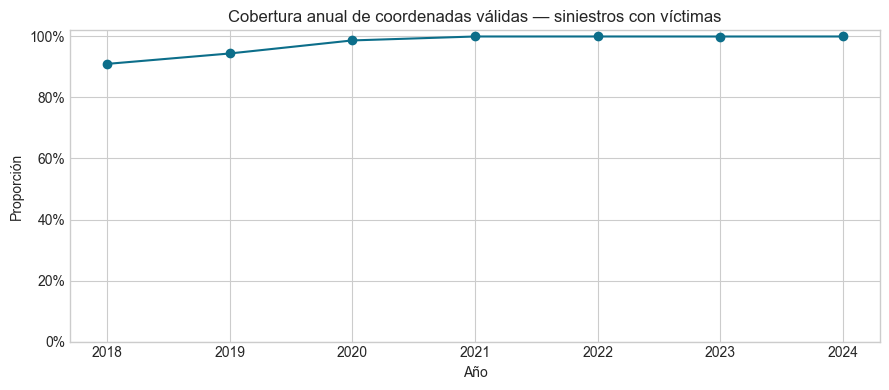

In [2]:
victimas['Coordenada_Completa'] = victimas[['Longitud','Latitud']].notna().all(axis=1)
victimas['Coordenada_Valida_Bogota'] = (
    victimas.Coordenada_Completa & victimas.Longitud.between(-74.30,-73.90) &
    victimas.Latitud.between(4.40,4.90)
)
coverage = (victimas.groupby('AA_Acc').agg(
    Siniestros=('Codigo_Accidente','size'),
    Coordenadas_Completas=('Coordenada_Completa','sum'),
    Coordenadas_Validas=('Coordenada_Valida_Bogota','sum'))
    .rename_axis('Anio').reset_index())
coverage['Cobertura_Valida'] = coverage.Coordenadas_Validas / coverage.Siniestros
coverage.to_csv(REPORTS_PATH/'cobertura_coordenadas.csv', index=False, encoding='utf-8-sig')
display(coverage)
ax=coverage.plot(x='Anio',y='Cobertura_Valida',marker='o',legend=False,figsize=(9,4),color='#0C6E8A')
ax.set(title='Cobertura anual de coordenadas válidas — siniestros con víctimas',ylabel='Proporción',xlabel='Año',ylim=(0,1.02))
ax.yaxis.set_major_formatter(lambda x,pos:f'{x:.0%}')
plt.tight_layout(); plt.savefig(REPORTS_PATH/'01_cobertura_coordenadas.png',dpi=170,bbox_inches='tight'); plt.show()

## 3. Distribución temporal y territorial

,Siniestros,Fallecidos,Con_Peaton,Con_Moto,Con_Bicicleta,Cobertura_Coordenadas,Participacion_Ciudad
Localidad,,,,,,,
KENNEDY,11879,444,2847,7070,2665,0.9866,0.1394
ENGATIVÁ,7877,315,1710,4558,1750,0.9905,0.0925
SUBA,7235,271,1720,3993,1814,0.9961,0.0849
BOSA,6250,246,1601,3639,1648,0.9619,0.0734
PUENTE ARANDA,6166,243,1181,3933,1107,0.9690,0.0724
FONTIBÓN,5356,258,972,3140,1204,0.9901,0.0629
USAQUÉN,4802,190,1095,2552,720,0.9704,0.0564
CIUDAD BOLÍVAR,4465,249,1493,2698,606,0.9702,0.0524
SAN CRISTÓBAL,3693,138,1224,2224,361,0.9540,0.0433


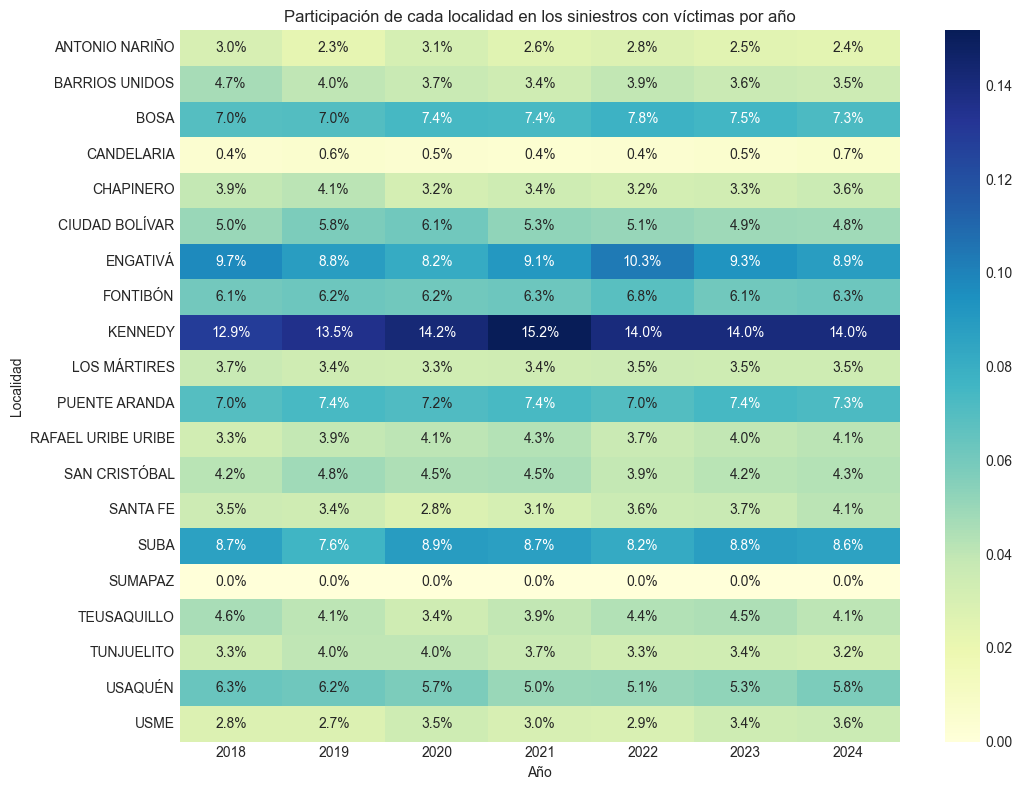

In [3]:
victimas['Franja_Horaria'] = pd.cut(victimas.Hora_Acc, bins=[-1,5,11,17,23],
    labels=['Madrugada','Mañana','Tarde','Noche'])
annual_locality = victimas.groupby(['Localidad','AA_Acc']).size().unstack(fill_value=0)
summary = victimas.groupby('Localidad').agg(
    Siniestros=('Codigo_Accidente','size'),
    Fallecidos=('Gravedad_Indicador_Tradicional',lambda s:(s=='Con Muertos').sum()),
    Con_Peaton=('Con_Peaton',lambda s:(s=='SI').sum()),
    Con_Moto=('Con_Moto',lambda s:(s=='SI').sum()),
    Con_Bicicleta=('Con_Bicicleta',lambda s:(s=='SI').sum()),
    Cobertura_Coordenadas=('Coordenada_Valida_Bogota','mean')).sort_values('Siniestros',ascending=False)
summary['Participacion_Ciudad'] = summary.Siniestros / summary.Siniestros.sum()
summary.to_csv(REPORTS_PATH/'resumen_localidades.csv',encoding='utf-8-sig')
display(summary.round(4))
plt.figure(figsize=(11,8)); sns.heatmap(annual_locality.div(annual_locality.sum(axis=0),axis=1),cmap='YlGnBu',fmt='.1%',annot=True)
plt.title('Participación de cada localidad en los siniestros con víctimas por año'); plt.xlabel('Año'); plt.ylabel('Localidad')
plt.tight_layout(); plt.savefig(REPORTS_PATH/'02_distribucion_anual_localidad.png',dpi=170,bbox_inches='tight'); plt.show()

## 4. Densidad espacial puntual

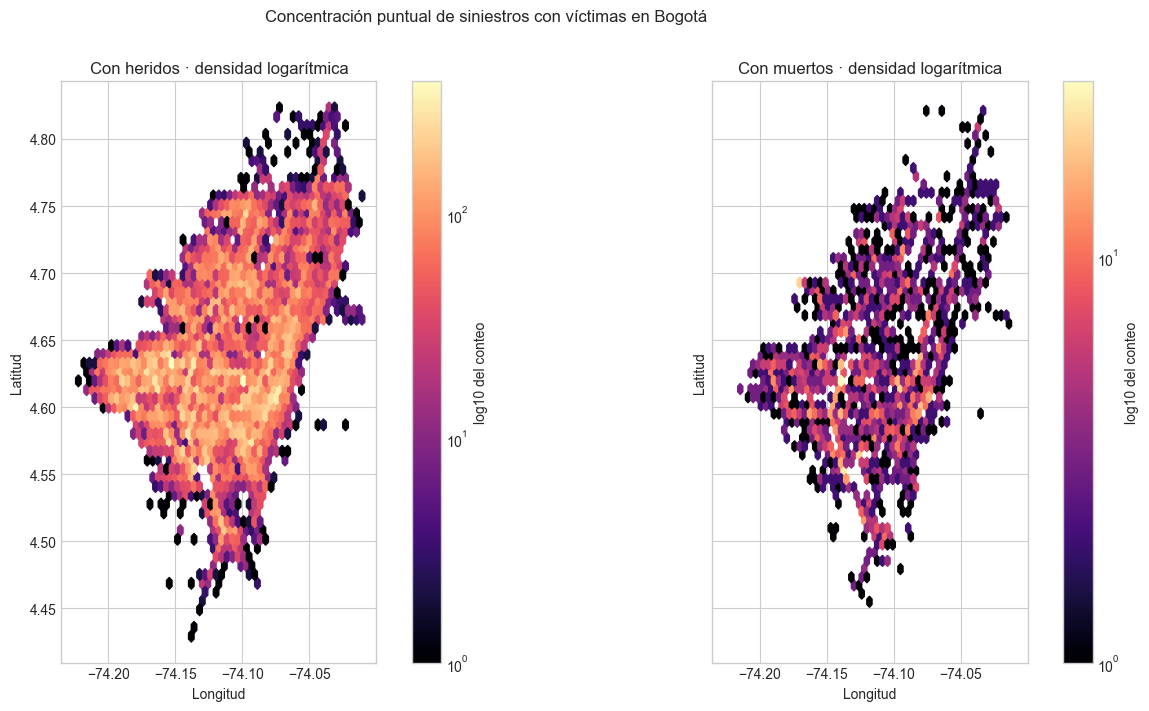

In [4]:
geo=victimas[victimas.Coordenada_Valida_Bogota].copy()
fig,axes=plt.subplots(1,2,figsize=(14,7),sharex=True,sharey=True)
for ax,(label,part) in zip(axes,[('Con heridos',geo[geo.Gravedad_Indicador_Tradicional=='Con Heridos']),('Con muertos',geo[geo.Gravedad_Indicador_Tradicional=='Con Muertos'])]):
    hb=ax.hexbin(part.Longitud,part.Latitud,gridsize=52,mincnt=1,cmap='magma',bins='log')
    ax.set(title=f'{label} · densidad logarítmica',xlabel='Longitud',ylabel='Latitud',aspect='equal')
    fig.colorbar(hb,ax=ax,label='log10 del conteo')
plt.suptitle('Concentración puntual de siniestros con víctimas en Bogotá',y=1.01)
plt.tight_layout(); plt.savefig(REPORTS_PATH/'03_densidad_espacial_victimas.png',dpi=180,bbox_inches='tight'); plt.show()

## 5. Centros espaciales y cuadrículas de concentración

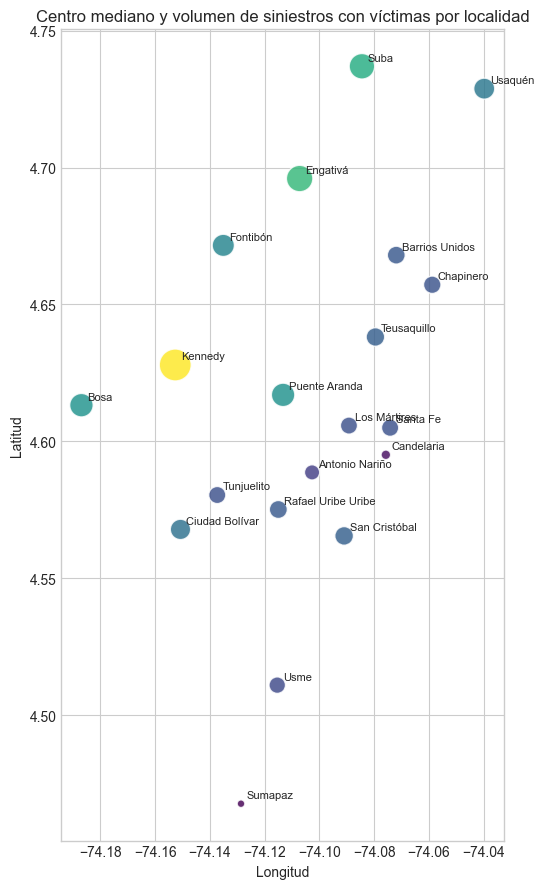

,Lon_Celda,Lat_Celda,Siniestros,Localidad_Dominante,Fallecidos
9317,-74.098,4.619,307,KENNEDY,11
4137,-74.138,4.631,113,KENNEDY,5
1351,-74.171,4.628,95,KENNEDY,3
3968,-74.139,4.573,93,TUNJUELITO,5
9711,-74.095,4.576,93,SAN CRISTÓBAL,3
6143,-74.120,4.679,92,FONTIBÓN,5
3333,-74.145,4.599,85,KENNEDY,7
12280,-74.075,4.611,85,SANTA FE,5
958,-74.179,4.597,79,BOSA,4
2539,-74.154,4.632,77,KENNEDY,5


In [5]:
centroids=(geo.groupby('Localidad').agg(Longitud=('Longitud','median'),Latitud=('Latitud','median'),Siniestros=('Codigo_Accidente','size')).reset_index())
fig,ax=plt.subplots(figsize=(10,9)); ax.scatter(centroids.Longitud,centroids.Latitud,s=30+500*centroids.Siniestros/centroids.Siniestros.max(),c=centroids.Siniestros,cmap='viridis',alpha=.82,edgecolor='white')
for _,r in centroids.iterrows(): ax.annotate(r.Localidad.title(),(r.Longitud,r.Latitud),xytext=(4,4),textcoords='offset points',fontsize=8)
ax.set(title='Centro mediano y volumen de siniestros con víctimas por localidad',xlabel='Longitud',ylabel='Latitud',aspect='equal')
plt.tight_layout(); plt.savefig(REPORTS_PATH/'04_centros_localidad.png',dpi=180,bbox_inches='tight'); plt.show()

geo['Lon_Celda']=geo.Longitud.round(3); geo['Lat_Celda']=geo.Latitud.round(3)
hotspots=(geo.groupby(['Lon_Celda','Lat_Celda']).agg(Siniestros=('Codigo_Accidente','size'),Localidad_Dominante=('Localidad',lambda s:s.mode().iat[0]),Fallecidos=('Gravedad_Indicador_Tradicional',lambda s:(s=='Con Muertos').sum())).reset_index().sort_values('Siniestros',ascending=False).head(25))
hotspots.to_csv(REPORTS_PATH/'top25_celdas_concentracion.csv',index=False,encoding='utf-8-sig')
display(hotspots)

## 6. Estabilidad 2018–2022 frente a 2023–2024

In [6]:
period = victimas.assign(Periodo=np.where(victimas.AA_Acc<=2022,'2018–2022','2023–2024'))
rates=(period.groupby(['Localidad','Periodo']).size().unstack(fill_value=0))
rates['Promedio_Anual_2018_2022']=rates['2018–2022']/5
rates['Promedio_Anual_2023_2024']=rates['2023–2024']/2
rates['Ratio_Post_Pre']=rates.Promedio_Anual_2023_2024/rates.Promedio_Anual_2018_2022
rates.sort_values('Ratio_Post_Pre').to_csv(REPORTS_PATH/'estabilidad_territorial_periodos.csv',encoding='utf-8-sig')
display(rates.sort_values('Ratio_Post_Pre').round(3))
print('Ratio ciudad:',round((rates['2023–2024'].sum()/2)/(rates['2018–2022'].sum()/5),3))

Periodo,2018–2022,2023–2024,Promedio_Anual_2018_2022,Promedio_Anual_2023_2024,Ratio_Post_Pre
Localidad,,,,,
SUMAPAZ,8,2,1.6,1.0,0.625
BARRIOS UNIDOS,2356,924,471.2,462.0,0.980
TUNJUELITO,2156,848,431.2,424.0,0.983
CIUDAD BOLÍVAR,3202,1263,640.4,631.5,0.986
ANTONIO NARIÑO,1614,637,322.8,318.5,0.987
CHAPINERO,2130,890,426.0,445.0,1.045
SAN CRISTÓBAL,2596,1097,519.2,548.5,1.056
USAQUÉN,3372,1430,674.4,715.0,1.060
ENGATIVÁ,5518,2359,1103.6,1179.5,1.069


Ratio ciudad: 1.093


## Conclusión

El análisis completa el componente espacial de la actividad 3.1 mediante control de coordenadas, distribución anual por localidad, densidad puntual, centros territoriales y cuadrículas de concentración. Las concentraciones son descriptivas y no deben interpretarse como efectos causales. La comparación territorial de periodos permite verificar si el universo con víctimas conserva una cobertura espacial razonablemente estable después de 2022.